# Thermodynamically Consistent Lattice ABP MIPS Demo

This notebook runs the `data.lattice_abp_tc` implementation of the Kim-Kwon-Baek thermodynamically consistent lattice Monte Carlo method. It saves true medium entropy production from accepted hops and provides simple diagnostics for MIPS-like density inhomogeneity.

The default configuration targets an NVIDIA L40S with `backend="cuda_fused"`. It fails fast if the JIT CUDA toolchain is unavailable instead of silently running the much slower Torch fallback. No time step, WCA cutoff, or update rule is approximated. For a quick check, reduce `n_steps`.

## 0. One-time L40S environment setup

Install the notebook packages into the **same Python environment as this Jupyter kernel**:

```bash
python -m pip install -r data/lattice_abp_tc/requirements-l40s.txt
```

PyTorch is intentionally installed separately: use the [official PyTorch selector](https://pytorch.org/get-started/locally/) and choose a CUDA-enabled wheel suitable for the host. This notebook only needs `torch`; `torchvision` and `torchaudio` are not used.

The fused backend also compiles CUDA source, so pip packages alone are not enough. Install an NVIDIA CUDA Toolkit containing `nvcc` plus a compatible host C++ compiler (`g++`/`c++` on Linux, MSVC Build Tools on Windows). See the [NVIDIA CUDA installation guide](https://docs.nvidia.com/cuda/cuda-installation-guide-linux/) and restart the Jupyter kernel after changing PyTorch or CUDA environment variables. A failed JIT load is cached in the Python process, so restart the kernel after fixing a build failure.

In [115]:
from pathlib import Path
import importlib.util
import os
import shutil
import subprocess
import sys


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "data" / "lattice_abp_tc" / "core.py").exists():
            return path
    raise RuntimeError("Could not find CNEEP_v2 repo root from the notebook working directory.")


ROOT = find_repo_root("/home/ldh041203/projects/CNEEP_v2")
GPU_REQUIREMENTS = ROOT / "data" / "lattice_abp_tc" / "requirements-l40s.txt"

# Set extension-discovery variables before importing torch or the simulator package.
bootstrap_nvcc = shutil.which("nvcc.exe" if os.name == "nt" else "nvcc")
if bootstrap_nvcc and "CUDA_HOME" not in os.environ:
    os.environ["CUDA_HOME"] = str(Path(bootstrap_nvcc).resolve().parents[1])
os.environ.setdefault("TORCH_CUDA_ARCH_LIST", "8.9")
os.environ.setdefault("MAX_JOBS", str(min(8, os.cpu_count() or 1)))

required_modules = ("numpy", "matplotlib", "tqdm", "ninja", "setuptools")
missing_modules = [name for name in required_modules if importlib.util.find_spec(name) is None]

if missing_modules:
    print("Installing missing notebook packages:", ", ".join(missing_modules))
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-r",
        str(GPU_REQUIREMENTS),
    ])
else:
    print("Notebook pip dependencies are already installed.")

if importlib.util.find_spec("torch") is None:
    raise RuntimeError(
        "PyTorch is not installed in this kernel. Install a CUDA-enabled torch wheel "
        "from https://pytorch.org/get-started/locally/ and restart the kernel."
    )

print("repo:", ROOT)
print("python:", sys.executable)

Notebook pip dependencies are already installed.
repo: /home/ldh041203/projects/CNEEP_v2
python: /home/ldh041203/.conda/envs/jupyter-gpu/bin/python


In [116]:
import json
import math
import os
import platform
import re
import shutil
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.cpp_extension import CUDA_HOME, is_ninja_available


if not torch.cuda.is_available():
    raise RuntimeError(
        f"This kernel cannot see CUDA (torch={torch.__version__}, "
        f"torch.version.cuda={torch.version.cuda}). Select the CUDA-enabled Jupyter kernel."
    )

DEVICE = torch.device("cuda:0")
gpu = torch.cuda.get_device_properties(DEVICE)
capability = torch.cuda.get_device_capability(DEVICE)
if capability != (8, 9):
    warnings.warn(
        f"Expected an L40S (compute capability 8.9), found {gpu.name} "
        f"with capability {capability[0]}.{capability[1]}."
    )

nvcc_name = "nvcc.exe" if os.name == "nt" else "nvcc"
nvcc = None
if CUDA_HOME is not None:
    candidate = Path(CUDA_HOME) / "bin" / nvcc_name
    if candidate.is_file():
        nvcc = str(candidate)
if nvcc is None:
    nvcc = shutil.which(nvcc_name)
host_compiler = (
    shutil.which("cl.exe")
    if os.name == "nt"
    else (shutil.which("c++") or shutil.which("g++") or shutil.which("clang++"))
)

toolchain_errors = []
if torch.version.cuda is None:
    toolchain_errors.append("Installed PyTorch is a CPU-only build.")
if CUDA_HOME is None:
    toolchain_errors.append("CUDA_HOME was not detected by torch.utils.cpp_extension.")
elif not (Path(CUDA_HOME) / "bin" / nvcc_name).is_file():
    toolchain_errors.append(f"CUDA_HOME={CUDA_HOME} does not contain bin/{nvcc_name}.")
if nvcc is None:
    toolchain_errors.append("nvcc was not found; install the CUDA Toolkit, not only a runtime wheel.")
if host_compiler is None:
    toolchain_errors.append("No compatible host C++ compiler was found on PATH.")
if not is_ninja_available():
    toolchain_errors.append("Ninja is unavailable in this kernel environment.")
if toolchain_errors:
    raise RuntimeError("L40S fused backend prerequisites failed:\n- " + "\n- ".join(toolchain_errors))

# L40S native architecture; MAX_JOBS prevents an oversized JIT build fan-out.
os.environ.setdefault("TORCH_CUDA_ARCH_LIST", "8.9")
os.environ.setdefault("MAX_JOBS", str(min(8, os.cpu_count() or 1)))
nvcc_output = subprocess.run(
    [nvcc, "--version"], capture_output=True, text=True, check=True
).stdout.strip()
nvcc_version = nvcc_output.splitlines()[-1]
version_match = re.search(r"release\s+(\d+)\.(\d+)", nvcc_output)
if version_match and torch.version.cuda:
    nvcc_major, nvcc_minor = map(int, version_match.groups())
    torch_major, torch_minor = map(int, torch.version.cuda.split(".")[:2])
    if nvcc_major != torch_major:
        raise RuntimeError(
            f"CUDA major mismatch: torch wheel={torch.version.cuda}, nvcc={nvcc_major}.{nvcc_minor}. "
            "Install a matching CUDA-enabled torch wheel or CUDA Toolkit."
        )
    if nvcc_minor != torch_minor:
        warnings.warn(
            f"CUDA minor versions differ: torch wheel={torch.version.cuda}, "
            f"nvcc={nvcc_major}.{nvcc_minor}. The JIT build will perform the final compatibility check."
        )

print(f"GPU: {gpu.name} ({gpu.total_memory / 2**30:.1f} GiB, sm_{capability[0]}{capability[1]})")
print(f"PyTorch: {torch.__version__}, wheel CUDA: {torch.version.cuda}")
print(f"CUDA_HOME: {CUDA_HOME}")
print(f"nvcc: {nvcc_version}")
print(f"host compiler: {host_compiler}")
print(f"platform: {platform.platform()}")

GPU: NVIDIA L40S (44.5 GiB, sm_89)
PyTorch: 2.6.0+cu124, wheel CUDA: 12.4
CUDA_HOME: /tools/cuda/cuda12.4
nvcc: Build cuda_12.4.r12.4/compiler.33961263_0
host compiler: /usr/bin/c++
platform: Linux-5.15.0-94-generic-x86_64-with-glibc2.27


In [117]:
# Compile/load the fused extension now, before launching a long simulation.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from data.lattice_abp_tc._cuda_backend import cuda_backend_buildable, load_cuda_backend

if not cuda_backend_buildable():
    raise RuntimeError("The fused CUDA backend is not buildable in this kernel; review the cell above.")
cuda_extension = load_cuda_backend(verbose=True)
print("fused CUDA extension ready:", cuda_extension.__name__)

from data.lattice_abp_tc import ThermodynamicLatticeABP, ThermodynamicLatticeABPParams

fused CUDA extension ready: lattice_abp_cuda_5fef8ea6bdae


In [118]:
# A tiny end-to-end CUDA check. This also exercises B>1 ensemble blocks.
smoke_params = ThermodynamicLatticeABPParams(
    N=8,
    L=5.0,
    grid_size=25,
    sigma=0.6,
    epsilon=10,
    v0=2.0,
    Dr=1.0,
    Dt=0.5,
    dt=1.0e-4,
    prefactor="cv",
    seed=123,
    device=str(DEVICE),
    backend="cuda_fused",
)
smoke_sim = ThermodynamicLatticeABP(smoke_params)
smoke = smoke_sim.simulate(
    B=2,
    n_steps=2,
    save_interval=1,
    show_progress=False,
    save_diagnostics=False,
    save_occupancy=True,
    save_exact_medium_ep=True,
)
rebuilt = smoke_sim.occupancy_from_sites(smoke["sites"][-1].to(DEVICE)).cpu()
assert torch.equal(rebuilt, smoke["occupancy"][-1])
assert bool(torch.isfinite(smoke["exact_medium_ep"]).all())
print("2-step fused CUDA smoke test passed.")
del smoke, smoke_sim
torch.cuda.empty_cache()

2-step fused CUDA smoke test passed.


/home/ldh041203/projects/CNEEP_v2/data/lattice_abp_tc/core.py:168: UserWarning: five_color uses the Torch tensor implementation; the legacy Numba/CUDA fused backends implement a different random-sequential update law.
  self.backend = self._resolve_backend(params.backend)


## 1. Main MIPS simulation

The optimization does not alter `dt`, particle count, WCA cutoff, or random-sequential updates. `B=1` advances one trajectory; increasing `B` improves independent-ensemble throughput on the L40S but does not make a single trajectory advance faster.

In [119]:
def n_from_packing_fraction(phi, box_size, sigma):
    return int(round(phi * 4.0 * box_size * box_size / (math.pi * sigma * sigma)))


# MIPS-friendly defaults. Use smaller n_steps for a smoke run.
L = 30.0
grid_size = 60
sigma = 0.5
phi = 0.30
N = n_from_packing_fraction(phi, L, sigma)

params = ThermodynamicLatticeABPParams(
    N=N,
    L=L,
    grid_size=grid_size,
    sigma=sigma,
    epsilon=3,
    v0=50.0,
    Dr=1.5,
    Dt=1,
    dt=1.0e-4,
    prefactor="cv",
    seed=7,
    device=str(DEVICE),  # cuda:0 / NVIDIA L40S
    dtype="float32",
    update_scheme="five_color",
    backend="torch",
)

quick_run = False  # set True only for a short notebook check
n_steps = 20 if quick_run else 100_000
burn_in = 0
save_interval = 5 if quick_run else 100
B = 1  # use 16 or 64 only when multiple independent replicas are wanted

sim = ThermodynamicLatticeABP(params)
print(
    f"device={sim.device}, L={params.L:g}, grid={params.grid_size}, dl={params.dl:g}, "
    f"N={params.N}, phi={params.phi:.3f}, Pe={params.Pe:.2f}, "
    f"gamma2={params.gamma2:.3g}, prefactor={params.prefactor}, backend={sim.backend}, "
    f"B={B}, n_steps={n_steps}, save_interval={save_interval}"
)

device=cuda:0, L=30, grid=60, dl=0.5, N=1375, phi=0.300, Pe=66.67, gamma2=2.5e+03, prefactor=cv, backend=torch, B=1, n_steps=100000, save_interval=100


In [120]:
import time

torch.cuda.synchronize(DEVICE)
started = time.perf_counter()
result = sim.simulate(
    B=B,
    burn_in=burn_in,
    n_steps=n_steps,
    save_interval=save_interval,
    show_progress=True,
    save_diagnostics=False,
    save_occupancy=True,
    save_exact_medium_ep=True,
)
elapsed = time.perf_counter() - started

print(f"elapsed: {elapsed:.2f} s, throughput: {B * n_steps / max(elapsed, 1e-12):.1f} ensemble sweeps/s")
print("sites", tuple(result["sites"].shape))
print("occupancy", tuple(result["occupancy"].shape))
print("exact_medium_ep", tuple(result["exact_medium_ep"].shape))

elapsed: 469.79 s, throughput: 212.9 ensemble sweeps/s
sites (1001, 1, 1375, 2)
occupancy (1001, 1, 60, 60)
exact_medium_ep (1, 1000)


In [121]:
initial_summary = sim.mips_summary_from_sites(result["sites"][0], include_coarse=False)
final_summary = sim.mips_summary_from_sites(result["sites"][-1], include_coarse=False)

summary = {
    "resolved_backend": sim.backend,
    "initial": initial_summary,
    "final": final_summary,
    "mean_exact_medium_ep_rate_by_ensemble": result["exact_medium_ep_rate"].mean(dim=1).numpy().tolist(),
}

print(json.dumps(summary, indent=2))

{
  "resolved_backend": "torch",
  "initial": {
    "site_density": 0.3819444444444444,
    "packing_fraction": 0.2999784651865254,
    "largest_site_cluster_fraction": 0.02909090909090909,
    "low_k_ratio": 0.8614348194826954,
    "particle_largest_cluster_fraction": 0.02909090909090909
  },
  "final": {
    "site_density": 0.3819444444444444,
    "packing_fraction": 0.2999784651865254,
    "largest_site_cluster_fraction": 0.8756363636363637,
    "low_k_ratio": 40.10862679964322,
    "particle_largest_cluster_fraction": 0.8756363636363637
  },
  "mean_exact_medium_ep_rate_by_ensemble": [
    548662.1875
  ]
}


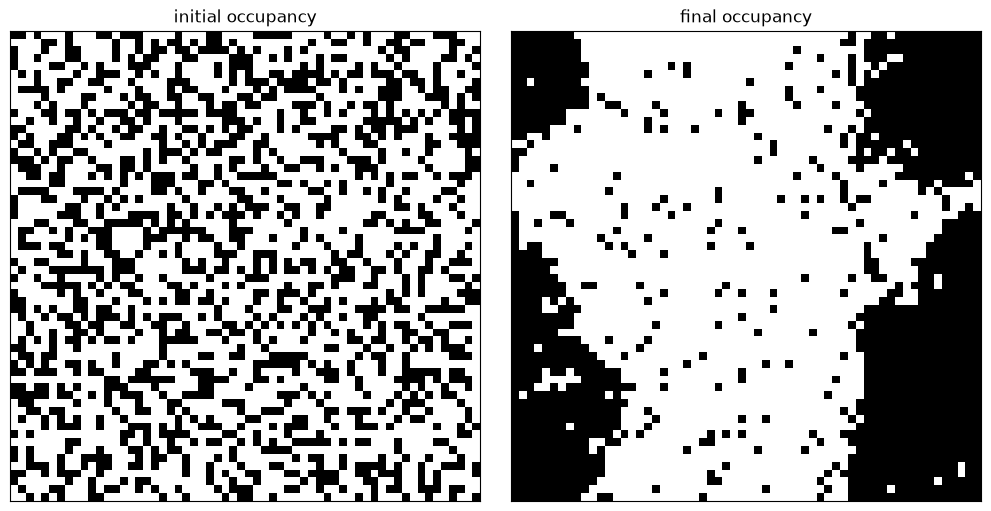

In [122]:
occ0 = result["occupancy"][0, 0].numpy()
occ1 = result["occupancy"][-1, 0].numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
for ax, image, title in zip(
    axes,
    (occ0, occ1),
    ("initial occupancy", "final occupancy"),
):
    nx, ny = image.shape
    ax.pcolormesh(
        np.arange(nx + 1),
        np.arange(ny + 1),
        (image.T > 0).astype(np.uint8),
        shading="flat",
        antialiased=False,
        cmap="gray_r",
        vmin=0,
        vmax=1,
    )
    ax.set_title(title)
    ax.set_xlim(0, nx)
    ax.set_ylim(0, ny)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

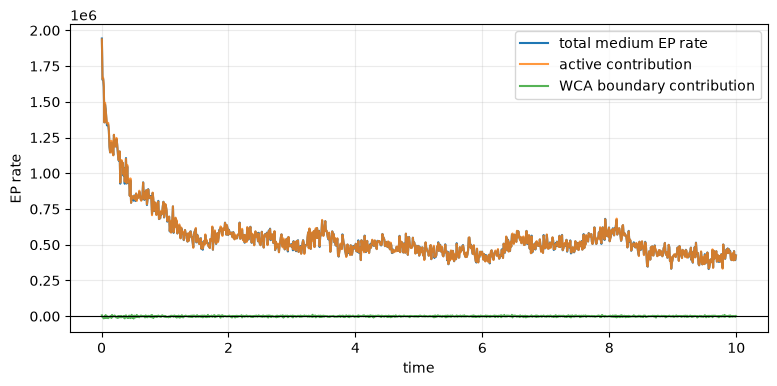

In [123]:
dt_saved = save_interval * params.dt
times_mid = result["times"][:-1].numpy() + 0.5 * dt_saved
ep_rate = result["exact_medium_ep_rate"][0].numpy()
active_rate = result["exact_active_medium_ep"][0].numpy() / dt_saved
wca_rate = result["exact_wca_medium_ep"][0].numpy() / dt_saved

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(times_mid, ep_rate, label="total medium EP rate")
ax.plot(times_mid, active_rate, label="active contribution", alpha=0.8)
ax.plot(times_mid, wca_rate, label="WCA boundary contribution", alpha=0.8)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("time")
ax.set_ylabel("EP rate")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

In [124]:
outdir = ROOT / "output" / "lattice_abp_tc_notebook"
outdir.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    outdir / "trajectory.npz",
    sites=result["sites"].numpy(),
    occupancy=result["occupancy"].numpy(),
    theta=result["theta"].numpy(),
    times=result["times"].numpy(),
    exact_medium_ep=result["exact_medium_ep"].numpy(),
    exact_medium_ep_rate=result["exact_medium_ep_rate"].numpy(),
)

with open(outdir / "summary.json", "w", encoding="utf-8") as f:
    json.dump({"params": params.__dict__, **summary}, f, indent=2)

print(f"Saved outputs under {outdir}")

Saved outputs under /home/ldh041203/projects/CNEEP_v2/output/lattice_abp_tc_notebook


In [125]:
from pathlib import Path

import imageio_ffmpeg
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import animation
import numpy as np

# mips_demo.ipynb에서 저장한 결과
NPZ_PATH = ROOT / "output" / "lattice_abp_tc_notebook" / "trajectory.npz"
MP4_PATH = NPZ_PATH.with_name("lattice_abp_mips.mp4")

ENSEMBLE_INDEX = 0
FRAME_STRIDE = 1   # 2면 한 프레임씩 건너뜀
FPS = 20
DPI = 160

if not NPZ_PATH.exists():
    raise FileNotFoundError(NPZ_PATH)

# imageio-ffmpeg가 제공하는 ffmpeg binary 사용
mpl.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()

with np.load(NPZ_PATH, allow_pickle=False) as data:
    if "occupancy" not in data:
        raise KeyError(
            f"{NPZ_PATH}에 'occupancy'가 없습니다. "
            "save_occupancy=True로 생성한 NPZ가 필요합니다."
        )

    occupancy = data["occupancy"]
    times = data["times"] if "times" in data else None

# 지원 형상:
# [T, B, G, G] 또는 [T, G, G]
if occupancy.ndim == 4:
    if not 0 <= ENSEMBLE_INDEX < occupancy.shape[1]:
        raise IndexError(
            f"ENSEMBLE_INDEX={ENSEMBLE_INDEX}, available=0..{occupancy.shape[1]-1}"
        )
    occupancy = occupancy[:, ENSEMBLE_INDEX]
elif occupancy.ndim != 3:
    raise ValueError(
        f"occupancy 형상은 [T,B,G,G] 또는 [T,G,G]여야 합니다: {occupancy.shape}"
    )

frame_indices = np.arange(0, occupancy.shape[0], FRAME_STRIDE)
grid_x, grid_y = occupancy.shape[-2:]

fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

# transpose 후 extent를 격자 경계로 지정하여 각 입자가 한 셀 전체를 채움
image = ax.imshow(
    (occupancy[frame_indices[0]].T > 0).astype(np.uint8),
    origin="lower",
    extent=(0, grid_x, 0, grid_y),
    interpolation="nearest",
    cmap="gray_r",
    vmin=0,
    vmax=1,
    aspect="equal",
)

ax.set_xlim(0, grid_x)
ax.set_ylim(0, grid_y)
ax.set_xticks([])
ax.set_yticks([])
title = ax.set_title("")

def update(frame_number):
    trajectory_index = int(frame_indices[frame_number])
    image.set_data(
        (occupancy[trajectory_index].T > 0).astype(np.uint8)
    )

    if times is not None and trajectory_index < len(times):
        title.set_text(
            f"Lattice ABP MIPS · t={float(times[trajectory_index]):.4f}"
        )
    else:
        title.set_text(
            f"Lattice ABP MIPS · frame {trajectory_index}"
        )

    return image, title

movie = animation.FuncAnimation(
    fig,
    update,
    frames=len(frame_indices),
    interval=1000 / FPS,
    blit=True,
)

writer = animation.FFMpegWriter(
    fps=FPS,
    codec="libx264",
    bitrate=3500,
    extra_args=["-pix_fmt", "yuv420p"],
)

movie.save(
    MP4_PATH,
    writer=writer,
    dpi=DPI,
)

plt.close(fig)

print(f"MP4 saved: {MP4_PATH.resolve()}")
print(f"frames: {len(frame_indices)}, fps: {FPS}")

MP4 saved: /home/ldh041203/projects/CNEEP_v2/output/lattice_abp_tc_notebook/lattice_abp_mips.mp4
frames: 1001, fps: 20


In [126]:
from IPython.display import FileLink, Video, display

display(Video(str(MP4_PATH), embed=True))

try:
    # Google Colab이면 다운로드 창 실행
    from google.colab import files
    files.download(str(MP4_PATH))
except ImportError:
    # 일반 Jupyter/JupyterLab이면 다운로드 링크 제공
    display(FileLink(str(MP4_PATH)))

/home/ldh041203/projects/CNEEP_v2/output/lattice_abp_tc_notebook/lattice_abp_mips.mp4